In [14]:
import pandas as pd
import numpy as np

Ue = 50e-3 # peak voltage

def calcBode(df):
    df['A'] = 20 * np.log10(df['Ua'] / Ue)
    df['phi'] = 360*df['f']*df['DeltaT']
    return df

df_I = calcBode(pd.read_csv("./data/BodeI.csv"))
df_NI = calcBode(pd.read_csv("./data/BodeNI.csv"))

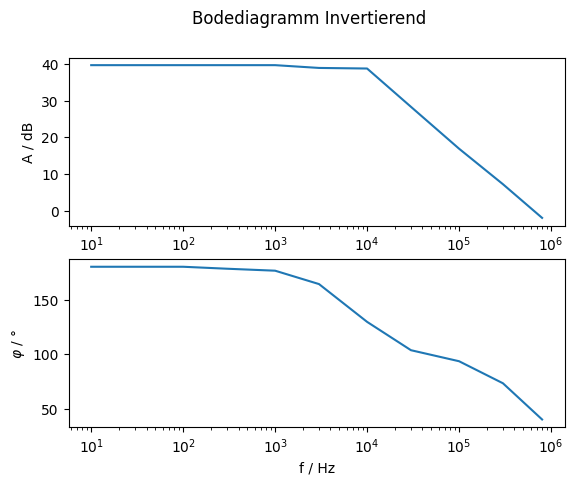

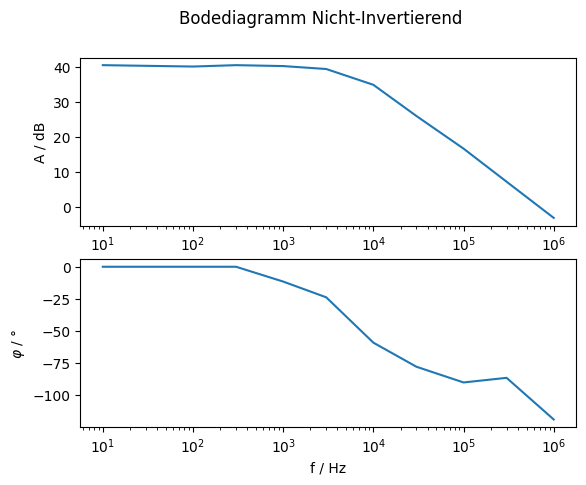

In [15]:
import matplotlib.pyplot as plt

def plot_bode(df):
    fig, (ax_abs, ax_arg) = plt.subplots(nrows=2, ncols=1)
    ax_abs.set_ylabel("A / dB")
    ax_abs.set_xscale('log')
    ax_abs.plot(df['f'], df['A'])

    ax_arg.set_xscale('log')
    ax_arg.set_xlabel("f / Hz")
    ax_arg.set_ylabel("$\\varphi$ / °")
    ax_arg.plot(df['f'], df['phi'])

    return fig

fig_I = plot_bode(df_I)
fig_I.suptitle('Bodediagramm Invertierend')
fig_I.savefig("./latex/images/bode_I.png")
fig_NI = plot_bode(df_NI)
fig_NI.suptitle('Bodediagramm Nicht-Invertierend')
fig_NI.savefig("./latex/images/bode_NI.png")


In [16]:
data = df_I.merge(df_NI, on='f', suffixes=('_I', '_NI') )
data

,f,Ua_I,DeltaT_I,A_I,phi_I,Ua_NI,DeltaT_NI,A_NI,phi_NI
0,10,4.800,5.000000e-02,39.645425,180.00,5.360,-0.000000e+00,40.603896,-0.00
1,100,4.800,5.000000e-03,39.645425,180.00,5.120,-0.000000e+00,40.205999,-0.00
2,300,4.800,1.650000e-03,39.645425,178.20,5.360,-0.000000e+00,40.603896,-0.00
3,1000,4.800,4.900000e-04,39.645425,176.40,5.200,-3.200000e-05,40.340667,-11.52
4,3000,4.400,1.520000e-04,38.889653,164.16,4.720,-2.200000e-05,39.499440,-23.76
5,10000,4.320,3.600000e-05,38.730275,129.60,2.800,-1.640000e-05,34.963761,-59.04
6,30000,1.300,9.600000e-06,28.299467,103.68,1.000,-7.200000e-06,26.020600,-77.76
7,100000,0.350,2.600000e-06,16.901961,93.60,0.340,-2.500000e-06,16.650178,-90.00
8,300000,0.115,6.800000e-07,7.234557,73.44,0.114,-8.000000e-07,7.158697,-86.40


In [17]:
latex = data.to_latex(
    index=False,
    formatters={
        'f': "{:.0e}".format
    }
)
print(latex)

\begin{tabular}{rrrrrrrrr}
\toprule
f & Ua_I & DeltaT_I & A_I & phi_I & Ua_NI & DeltaT_NI & A_NI & phi_NI \\
\midrule
1e+01 & 4.800000 & 0.050000 & 39.645425 & 180.000000 & 5.360000 & -0.000000 & 40.603896 & -0.000000 \\
1e+02 & 4.800000 & 0.005000 & 39.645425 & 180.000000 & 5.120000 & -0.000000 & 40.205999 & -0.000000 \\
3e+02 & 4.800000 & 0.001650 & 39.645425 & 178.200000 & 5.360000 & -0.000000 & 40.603896 & -0.000000 \\
1e+03 & 4.800000 & 0.000490 & 39.645425 & 176.400000 & 5.200000 & -0.000032 & 40.340667 & -11.520000 \\
3e+03 & 4.400000 & 0.000152 & 38.889653 & 164.160000 & 4.720000 & -0.000022 & 39.499440 & -23.760000 \\
1e+04 & 4.320000 & 0.000036 & 38.730275 & 129.600000 & 2.800000 & -0.000016 & 34.963761 & -59.040000 \\
3e+04 & 1.300000 & 0.000010 & 28.299467 & 103.680000 & 1.000000 & -0.000007 & 26.020600 & -77.760000 \\
1e+05 & 0.350000 & 0.000003 & 16.901961 & 93.600000 & 0.340000 & -0.000003 & 16.650178 & -90.000000 \\
3e+05 & 0.115000 & 0.000001 & 7.234557 & 73.440000 & 0